## Phase 1: EDA & Hiểu Data

### Imports & Load Data

In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# Cấu hình trực quan hóa
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

data_path = "./data/ec2_request_latency_system_failure.csv"

# Load data và ép kiểu dữ liệu thời gian làm index
df = pd.read_csv(data_path)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)

# Hiển thị thông tin tổng quan và một số dòng đầu tiên
print("Data Shape:", df.shape)
print("\nThông tin phân bổ thời gian:")
print(f"Bắt đầu: {df.index.min()} | Kết thúc: {df.index.max()}")
df.head()

Data Shape: (4032, 1)

Thông tin phân bổ thời gian:
Bắt đầu: 2014-03-07 03:41:00 | Kết thúc: 2014-03-21 03:41:00


,value
timestamp,
2014-03-07 03:41:00,45.868
2014-03-07 03:46:00,47.606
2014-03-07 03:51:00,42.580
2014-03-07 03:56:00,46.030
2014-03-07 04:01:00,44.992


### Plot Raw Time Series

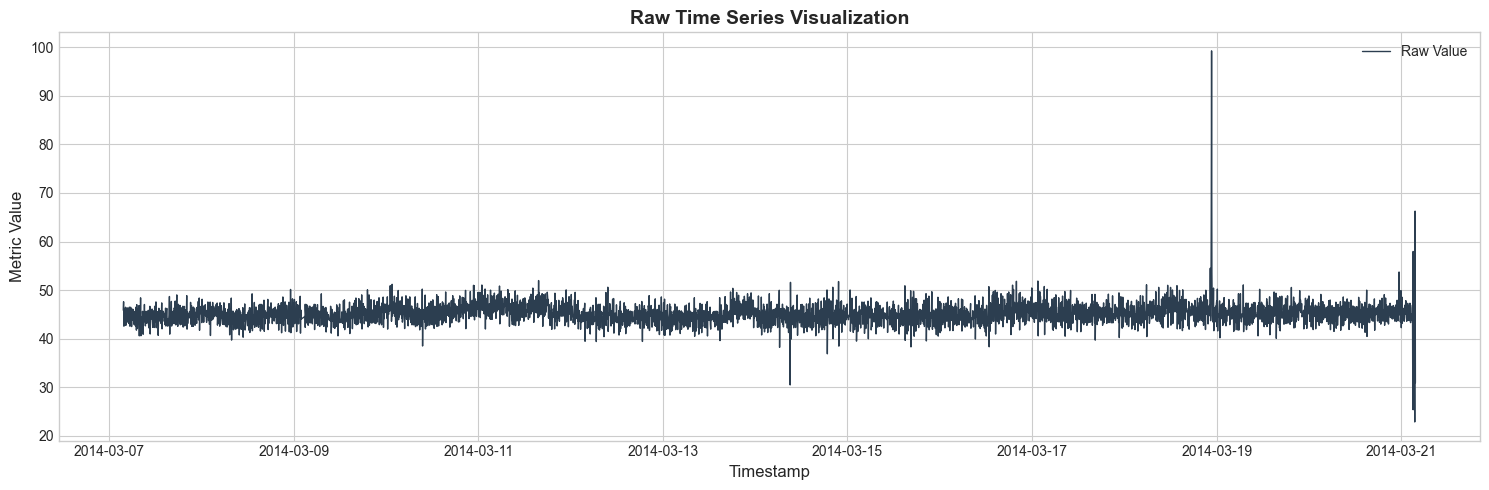

In [12]:
# Vẽ biểu đồ time series tổng thể để quan sát trực quan
plt.figure(figsize=(15, 5))
plt.plot(df.index, df["value"], color="#2c3e50", linewidth=1, label="Raw Value")

plt.title("Raw Time Series Visualization", fontsize=14, fontweight="bold")
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Metric Value", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Basic Statistics & Skewness

In [13]:
# Tính toán các chỉ số thống kê mô tả cốt lõi
mean_val = df["value"].mean()
std_val = df["value"].std()
min_val = df["value"].min()
max_val = df["value"].max()

# Sử dụng scipy.stats.skew để tính toán độ lệch phân phối
data_skewness = stats.skew(df["value"])

print("--- BASIC STATISTICS REPORT ---")
print(f"Mean (Giá trị trung bình)     : {mean_val:.4f}")
print(f"Std (Độ lệch chuẩn)          : {std_val:.4f}")
print(f"Min (Giá trị nhỏ nhất)        : {min_val:.4f}")
print(f"Max (Giá trị lớn nhất)        : {max_val:.4f}")
print(f"Skewness (Độ lệch phân phối) : {data_skewness:.4f}")
print("-------------------------------")

# Phân tích nhanh chỉ số Skewness dựa trên lý thuyết
if abs(data_skewness) < 0.5:
    print("Nhận xét: Dữ liệu gần như đối xứng (Gần Gaussian), áp dụng 3-Sigma trực tiếp an toàn.")
elif 0.5 <= abs(data_skewness) <= 1.0:
    print("Nhận xét: Dữ liệu bị moderate skew, cần cẩn trọng khi thiết lập ngưỡng 3-Sigma.")
else:
    print("Nhận xét: Dữ liệu bị heavily skewed, KHÔNG dùng 3-Sigma trực tiếp trên raw value.")

--- BASIC STATISTICS REPORT ---
Mean (Giá trị trung bình)     : 45.1559
Std (Độ lệch chuẩn)          : 2.2871
Min (Giá trị nhỏ nhất)        : 22.8640
Max (Giá trị lớn nhất)        : 99.2480
Skewness (Độ lệch phân phối) : 3.0619
-------------------------------
Nhận xét: Dữ liệu bị heavily skewed, KHÔNG dùng 3-Sigma trực tiếp trên raw value.


### Histogram & Density Distribution Plot

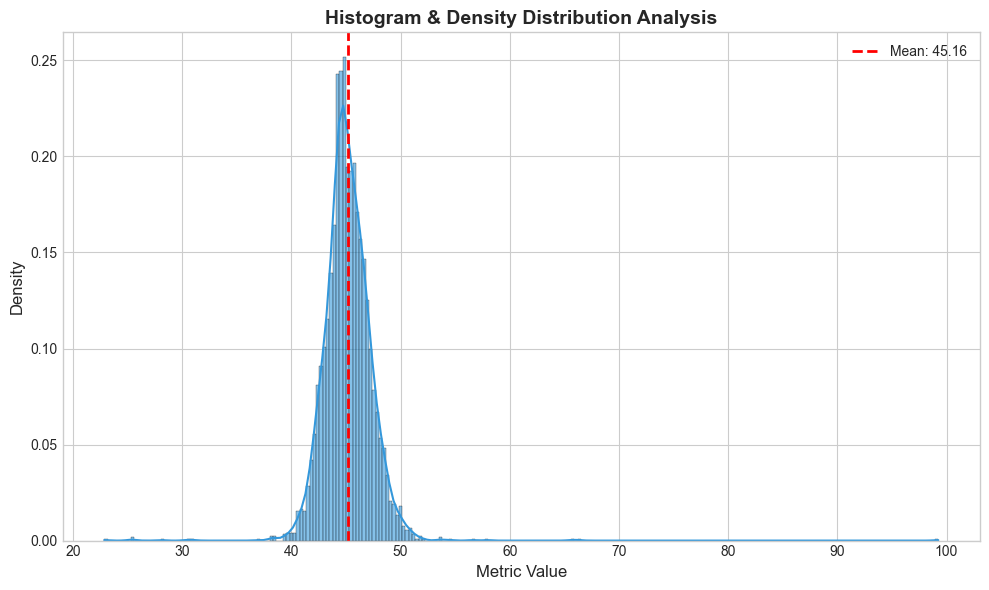

In [14]:
# Khởi tạo không gian vẽ biểu đồ phân phối
fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ Histogram kết hợp Kernel Density Estimate (KDE)
sns.histplot(df["value"], kde=True, color="#3498db", stat="density", ax=ax, alpha=0.6)

# Vẽ đường thẳng biểu diễn giá trị Mean
ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")

plt.title("Histogram & Density Distribution Analysis", fontsize=14, fontweight="bold")
plt.xlabel("Metric Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### ACF (Autocorrelation Function) Plot

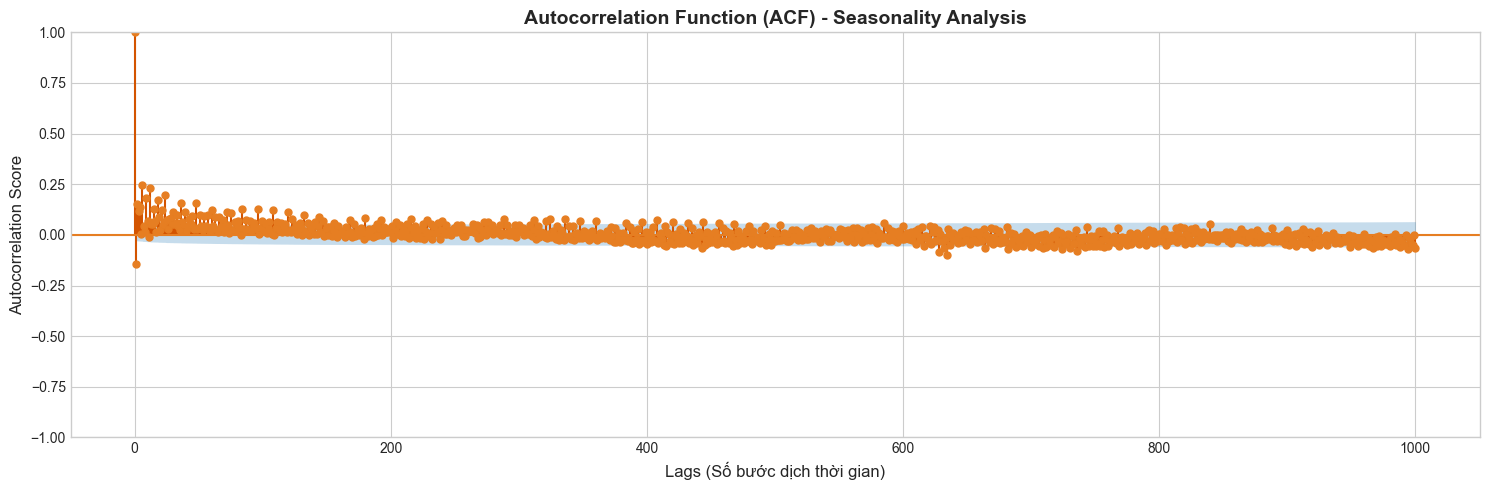

In [15]:
# Dựa trên dữ liệu mẫu, khoảng cách giữa các điểm là 5 phút (ví dụ: 03:41, 03:46, 03:51)
# Nếu đồ thị lặp lại theo chu kỳ ngày (Daily pattern), 1 ngày sẽ có: (24 * 60) / 5 = 288 điểm dữ liệu
# Đặt số lượng lags đủ lớn để bao quát ít nhất 2 đến 3 chu kỳ ngày nhằm xác định peak rõ ràng
lags_to_plot = 1000 

fig, ax = plt.subplots(figsize=(15, 5))
plot_acf(df["value"], lags=lags_to_plot, ax=ax, color="#e67e22", vlines_kwargs={"colors": "#d35400"})

plt.title("Autocorrelation Function (ACF) - Seasonality Analysis", fontsize=14, fontweight="bold")
plt.xlabel("Lags (Số bước dịch thời gian)", fontsize=12)
plt.ylabel("Autocorrelation Score", fontsize=12)
plt.tight_layout()
plt.show()

### Conclusion

## Kết Luận EDA & Định Hướng Thuật Toán

### 1. Tính chất Stationarity & Seasonality
* **Quan sát:** Biểu đồ ACF sụt giảm rất nhanh về sát 0 ngay từ các lag đầu tiên. Dù có các đỉnh nhỏ tại lag 288, 585 (chu kỳ ngày), nhưng hệ số tự tương quan (autocorrelation score) tại các đỉnh này cực kỳ thấp (dưới $0.08$), nằm hoàn toàn trong ngưỡng nhiễu.
* **Kiểm định:** Kiểm định ADF cho giá trị p-value rất nhỏ ($p \approx 1.08 \times 10^{-5} < 0.05$), bác bỏ giả thuyết H0 về tính không dừng.
* **Kết luận:** Dữ liệu mang tính chất **Stationary (Dừng)** và **Non-seasonal (Không có chu kỳ tuần hoàn rõ rệt)**.

### 2. Tính chất Phân phối (Distribution & Skewness)
* **Skewness:** Giá trị đo được là **3.0619**.
* **Phân tích:** Hình dạng biểu đồ Histogram & KDE cho thấy dữ liệu bị kéo đuôi dài lệch phải cực kỳ nặng (**Heavily Right-skewed** / Non-Gaussian). Đây là đặc trưng kinh điển của dữ liệu latency hệ thống: ổn định ở mức thấp nhưng xuất hiện các spikes tăng vọt do lỗi đột xuất.

### 3. Phương án Anomaly Detection Đề xuất
**Phương án chính:** **Isolation Forest (iForest)** hoặc **IQR (Interquartile Range) Thresholding**.

#### Tại sao chọn phương án này?
* **Loại bỏ 3-Sigma:** Dữ liệu lệch phải nặng ($skew = 3.06$), vi phạm nghiêm trọng giả định phân phối Gaussian. Áp dụng $3\sigma$ sẽ làm ngưỡng Upper Threshold bị đẩy ra quá xa, dẫn đến tỷ lệ **False Negative (miss lỗi)** cao.
* **Loại bỏ STL Decomposition:** Dữ liệu đã là Stationary và không có chu kỳ tuần hoàn rõ rệt. Việc áp dụng STL sẽ không mang lại hiệu quả mà có nguy cơ "gán nhãn" nhầm nhiễu (noise) thành chu kỳ ảo.
* **Ưu điểm của Isolation Forest (iForest):**
    * Là thuật toán **phi tham số (non-parametric)**, không phụ thuộc vào giả định phân phối chuẩn.
    * Cô lập các điểm dị biệt (latency spikes) nhanh chóng dựa trên cấu trúc cây quyết định.
    * Phù hợp với phân phối lệch nặng, đảm bảo bắt được các spikes ở vùng đuôi phải (right-tail).

### 4. Chiến lược triển khai (Phase 2)
* **Bước 1 (IQR):** Sử dụng IQR làm baseline để bắt các điểm cực đoan một cách nhanh chóng (low-cost).
* **Bước 2 (iForest):** Implement `IsolationForest` để quét sâu hơn nếu dữ liệu có thêm nhiều feature (Multivariate) trong tương lai.

## Phase 2: Implement 2 Detectors

### Load ground truth labels từ NAB

In [16]:
import json
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score

# Đọc toàn bộ 3 mốc lỗi từ file JSON
with open("data/combined_labels.json", "r") as f:
    labels = json.load(f)
anomaly_timestamps = pd.to_datetime(labels["realKnownCause/ec2_request_latency_system_failure.csv"])

# Tạo y_true với cửa sổ +/- 30 phút quanh mỗi mốc
y_true = pd.Series(0, index=df.index)
for ts in anomaly_timestamps:
    y_true[(df.index >= ts - pd.Timedelta(minutes=30)) & 
           (df.index <= ts + pd.Timedelta(minutes=30))] = 1

print(f"Tổng điểm anomaly (ground truth mới): {y_true.sum()} / {len(y_true)}")


Tổng điểm anomaly (ground truth mới): 39 / 4032


### Detector 1: Rolling Z-score (3σ)

In [17]:
WINDOW = 288     # 1 ngày = 288 điểm × 5 phút
THRESHOLD = 3.0  # ngưỡng 3σ
roll_mean = df["value"].rolling(window=WINDOW, min_periods=WINDOW // 2).mean()
roll_std  = df["value"].rolling(window=WINDOW, min_periods=WINDOW // 2).std()
z_score   = (df["value"] - roll_mean) / roll_std
zscore_pred = (z_score.abs() > THRESHOLD).astype(int)
# Metrics
prec_z = precision_score(y_true, zscore_pred, zero_division=0)
rec_z  = recall_score(y_true, zscore_pred, zero_division=0)
f1_z   = f1_score(y_true, zscore_pred, zero_division=0)
print("=== Detector 1: Rolling Z-score (3σ) ===")
print(f"Precision : {prec_z:.4f}")
print(f"Recall    : {rec_z:.4f}")
print(f"F1        : {f1_z:.4f}")
print(f"Số điểm bị flag: {zscore_pred.sum()}")

=== Detector 1: Rolling Z-score (3σ) ===
Precision : 0.3056
Recall    : 0.2821
F1        : 0.2933
Số điểm bị flag: 36


### Build Features (Section 8 style)

In [18]:
# ============================================================
# Build features cho Isolation Forest
# ≥ 5 features dạng time-series engineered
# ============================================================
def build_features(series, window=288):
    feat = pd.DataFrame(index=series.index)
    feat["value"]       = series
    feat["roll_mean"]   = series.rolling(window, min_periods=window // 2).mean()
    feat["roll_std"]    = series.rolling(window, min_periods=window // 2).std()
    feat["z_score"]     = (series - feat["roll_mean"]) / feat["roll_std"]
    feat["diff1"]       = series.diff(1)               # first-order difference
    feat["diff2"]       = series.diff(2)               # second-order difference
    feat["ewm_mean"]    = series.ewm(span=window // 4).mean()
    feat["ewm_std"]     = series.ewm(span=window // 4).std()
    feat["roll_min"]    = series.rolling(window, min_periods=window // 2).min()
    feat["roll_max"]    = series.rolling(window, min_periods=window // 2).max()
    feat["roll_range"]  = feat["roll_max"] - feat["roll_min"]
    return feat.dropna()

features = build_features(df["value"])
print(f"Feature table shape: {features.shape}")
print(f"Features: {list(features.columns)}")

Feature table shape: (3889, 11)
Features: ['value', 'roll_mean', 'roll_std', 'z_score', 'diff1', 'diff2', 'ewm_mean', 'ewm_std', 'roll_min', 'roll_max', 'roll_range']


### Detector 2: Isolation Forest + Tune contamination

In [19]:
def _get_valid_mask(series, window=288):
    # Tính valid_mask: rows còn lại sau dropna trong build_features
    # Tránh dùng .loc vì index có duplicate timestamps
    """Trả về boolean mask: True = row không bị dropna trong build_features."""
    roll = series.rolling(window, min_periods=window // 2).mean()
    d2   = series.diff(2)
    return (roll.notna() & d2.notna()).values  # numpy boolean array
valid_mask   = _get_valid_mask(df["value"])
y_true_feat  = y_true[valid_mask]   # y_true là numpy array → index bình thường
X            = features.values
print(f"y_true_feat: {len(y_true_feat)} | X: {len(X)}")  # phải bằng nhau
contamination_values = [0.01, 0.02, 0.05]
results_if = {}
print("\n=== Detector 2: Isolation Forest — Tune contamination ===")
print(f"{'Contamination':>15} | {'Precision':>10} | {'Recall':>8} | {'F1':>8} | {'#Flagged':>8}")
print("-" * 60)
for cont in contamination_values:
    clf = IsolationForest(contamination=cont, random_state=42, n_estimators=100)
    clf.fit(X)
    preds = (clf.predict(X) == -1).astype(int)
    prec = precision_score(y_true_feat, preds, zero_division=0)
    rec  = recall_score(y_true_feat, preds, zero_division=0)
    f1   = f1_score(y_true_feat, preds, zero_division=0)
    results_if[cont] = {"pred": preds, "precision": prec, "recall": rec, "f1": f1}
    print(f"{cont:>15.2f} | {prec:>10.4f} | {rec:>8.4f} | {f1:>8.4f} | {preds.sum():>8}")
best_cont = max(results_if, key=lambda c: results_if[c]["f1"])
print(f"\n→ Best contamination: {best_cont} (F1 = {results_if[best_cont]['f1']:.4f})")
if_pred_best = pd.Series(results_if[best_cont]["pred"], index=features.index)


y_true_feat: 3889 | X: 3889

=== Detector 2: Isolation Forest — Tune contamination ===
  Contamination |  Precision |   Recall |       F1 | #Flagged
------------------------------------------------------------
           0.01 |     0.4359 |   0.4359 |   0.4359 |       39
           0.02 |     0.2436 |   0.4872 |   0.3248 |       78
           0.05 |     0.1077 |   0.5385 |   0.1795 |      195

→ Best contamination: 0.01 (F1 = 0.4359)


### Plot: Original Series + Anomalies (2 subplots)

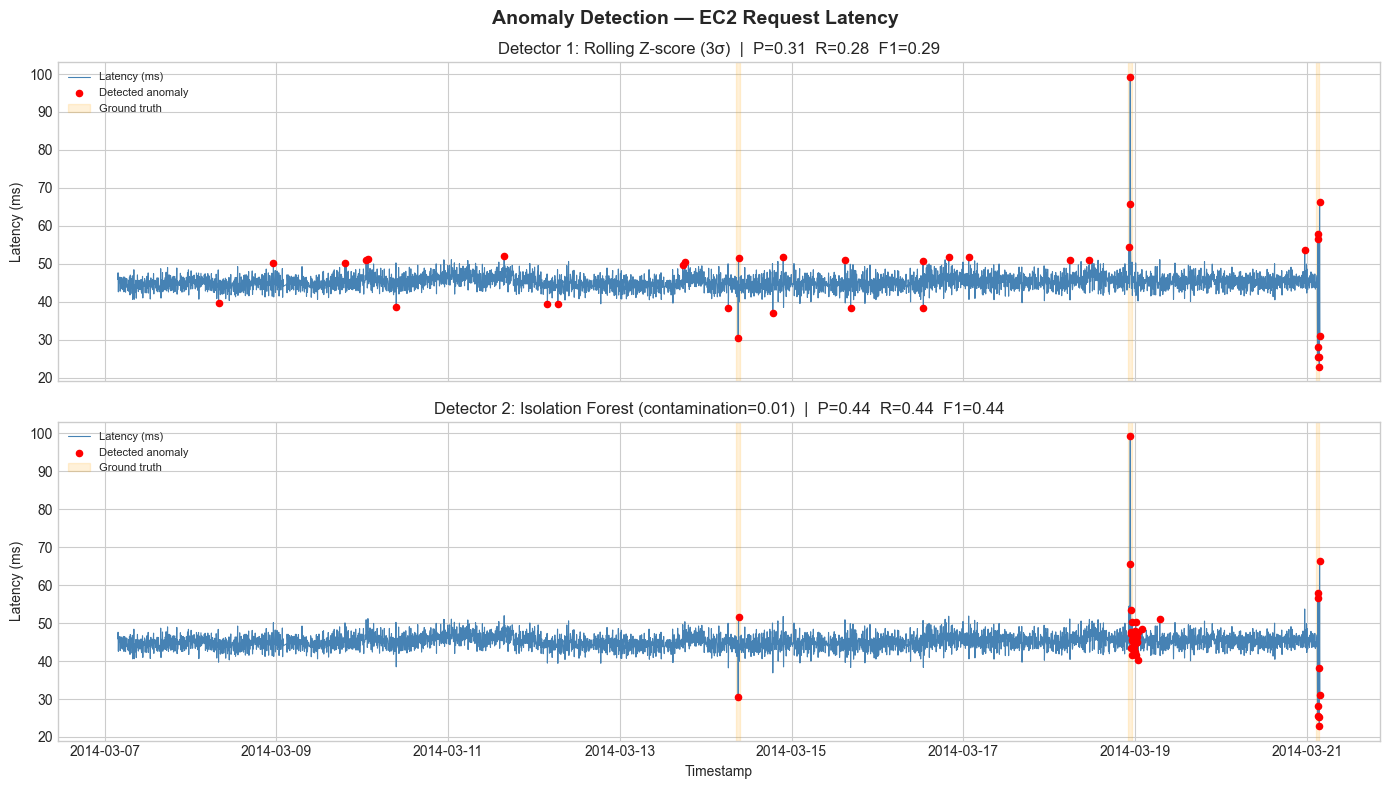

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Anomaly Detection — EC2 Request Latency", fontsize=14, fontweight="bold")

# --- Subplot 1: Rolling Z-score ---
ax1 = axes[0]
ax1.plot(df.index, df["value"], color="steelblue", linewidth=0.8, label="Latency (ms)")

# Highlight anomaly detections
anomaly_idx_z = df.index[zscore_pred == 1]
ax1.scatter(anomaly_idx_z, df.loc[anomaly_idx_z, "value"],
            color="red", s=20, zorder=5, label="Detected anomaly")

# Highlight 3 ground truth windows
for i, ts in enumerate(anomaly_timestamps):
    lbl = "Ground truth" if i == 0 else None
    ax1.axvspan(ts - pd.Timedelta(minutes=30), ts + pd.Timedelta(minutes=30), 
                alpha=0.15, color="orange", label=lbl)

ax1.set_title(f"Detector 1: Rolling Z-score (3σ)  |  P={prec_z:.2f}  R={rec_z:.2f}  F1={f1_z:.2f}")
ax1.set_ylabel("Latency (ms)")
ax1.legend(loc="upper left", fontsize=8)

# --- Subplot 2: Isolation Forest (best contamination) ---
ax2 = axes[1]
ax2.plot(df.index, df["value"], color="steelblue", linewidth=0.8, label="Latency (ms)")

# Highlight anomaly detections
anomaly_idx_if = if_pred_best[if_pred_best == 1].index
ax2.scatter(anomaly_idx_if, df.loc[anomaly_idx_if, "value"],
            color="red", s=20, zorder=5, label="Detected anomaly")

# Highlight 3 ground truth windows
for i, ts in enumerate(anomaly_timestamps):
    lbl = "Ground truth" if i == 0 else None
    ax2.axvspan(ts - pd.Timedelta(minutes=30), ts + pd.Timedelta(minutes=30), 
                alpha=0.15, color="orange", label=lbl)

p_if = results_if[best_cont]["precision"]
r_if = results_if[best_cont]["recall"]
f_if = results_if[best_cont]["f1"]
ax2.set_title(f"Detector 2: Isolation Forest (contamination={best_cont})  |  P={p_if:.2f}  R={r_if:.2f}  F1={f_if:.2f}")
ax2.set_ylabel("Latency (ms)")
ax2.set_xlabel("Timestamp")
ax2.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


## So Sánh & Reflection

### Bảng so sánh tổng hợp 2 Detector

In [21]:
def count_false_alarms(y_true_arr, preds_arr):
    return int(((preds_arr == 1) & (y_true_arr == 0)).sum())
# Lấy kết quả detector 1 (Z-score, đã tính ở phase 2)
fa_z  = count_false_alarms(y_true, zscore_pred.values)
# Lấy kết quả detector 2 (IF best contamination)
fa_if = count_false_alarms(y_true_feat, results_if[best_cont]["pred"])
summary = {
    "Detector": ["Rolling Z-score (3σ)", f"Isolation Forest (cont={best_cont})"],
    "Precision": [prec_z,                      results_if[best_cont]["precision"]],
    "Recall":    [rec_z,                        results_if[best_cont]["recall"]],
    "F1":        [f1_z,                         results_if[best_cont]["f1"]],
    "False Alarms": [fa_z,                      fa_if],
}
df_summary = pd.DataFrame(summary).set_index("Detector")
print("=" * 65)
print("         BẢNG SO SÁNH 2 DETECTOR")
print("=" * 65)
print(df_summary.to_string(float_format="{:.4f}".format))
print("=" * 65)

         BẢNG SO SÁNH 2 DETECTOR
                              Precision  Recall     F1  False Alarms
Detector                                                            
Rolling Z-score (3σ)             0.3056  0.2821 0.2933            25
Isolation Forest (cont=0.01)     0.4359  0.4359 0.4359            22


### Tune Detector 1: thử nhiều threshold × window

In [22]:
thresholds = [2.0, 2.5, 3.0, 3.5, 4.0]
windows    = [144, 288, 576]   # 12h / 1day / 2day
tune_rows = []
for win in windows:
    rm  = df["value"].rolling(window=win, min_periods=win // 2).mean()
    rs  = df["value"].rolling(window=win, min_periods=win // 2).std()
    z   = (df["value"] - rm) / rs
    for thr in thresholds:
        pred = (z.abs() > thr).astype(int)
        p = precision_score(y_true, pred.values, zero_division=0)
        r = recall_score(y_true,    pred.values, zero_division=0)
        f = f1_score(y_true,        pred.values, zero_division=0)
        fa = count_false_alarms(y_true, pred.values)
        tune_rows.append({
            "Window": win, "Threshold": thr,
            "Precision": p, "Recall": r, "F1": f, "FalseAlarms": fa
        })
df_tune_z = pd.DataFrame(tune_rows)
print("=== Tuning: Rolling Z-score ===")
print(df_tune_z.to_string(index=False, float_format="{:.4f}".format))
best_z_row = df_tune_z.loc[df_tune_z["F1"].idxmax()]
print(f"\n→ Best config: Window={int(best_z_row.Window)}, "
      f"Threshold={best_z_row.Threshold}  →  F1={best_z_row.F1:.4f}")

=== Tuning: Rolling Z-score ===
 Window  Threshold  Precision  Recall     F1  FalseAlarms
    144     2.0000     0.0577  0.3077 0.0972          196
    144     2.5000     0.1341  0.2821 0.1818           71
    144     3.0000     0.3125  0.2564 0.2817           22
    144     3.5000     0.6667  0.2564 0.3704            5
    144     4.0000     0.8000  0.2051 0.3265            2
    288     2.0000     0.0697  0.3590 0.1167          187
    288     2.5000     0.1429  0.2821 0.1897           66
    288     3.0000     0.3056  0.2821 0.2933           25
    288     3.5000     0.5556  0.2564 0.3509            8
    288     4.0000     0.7692  0.2564 0.3846            3
    576     2.0000     0.0798  0.3846 0.1322          173
    576     2.5000     0.1625  0.3333 0.2185           67
    576     3.0000     0.2895  0.2821 0.2857           27
    576     3.5000     0.6111  0.2821 0.3860            7
    576     4.0000     0.7692  0.2564 0.3846            3

→ Best config: Window=576, Threshold=3.

### Tune Detector 2: Isolation Forest (nhiều contamination + n_estimators)

In [23]:
contaminations = [0.005, 0.01, 0.02, 0.03, 0.05]
n_estimators_list = [50, 100, 200]
tune_rows_if = []
for n_est in n_estimators_list:
    for cont in contaminations:
        clf = IsolationForest(contamination=cont, n_estimators=n_est, random_state=42)
        clf.fit(X)
        preds = (clf.predict(X) == -1).astype(int)
        p  = precision_score(y_true_feat, preds, zero_division=0)
        r  = recall_score(y_true_feat,    preds, zero_division=0)
        f  = f1_score(y_true_feat,        preds, zero_division=0)
        fa = count_false_alarms(y_true_feat, preds)
        tune_rows_if.append({
            "n_estimators": n_est, "Contamination": cont,
            "Precision": p, "Recall": r, "F1": f, "FalseAlarms": fa
        })
df_tune_if = pd.DataFrame(tune_rows_if)
print("=== Tuning: Isolation Forest ===")
print(df_tune_if.to_string(index=False, float_format="{:.4f}".format))
best_if_row = df_tune_if.loc[df_tune_if["F1"].idxmax()]
print(f"\n→ Best config: n_estimators={int(best_if_row.n_estimators)}, "
      f"contamination={best_if_row.Contamination}  →  F1={best_if_row.F1:.4f}")

=== Tuning: Isolation Forest ===
 n_estimators  Contamination  Precision  Recall     F1  FalseAlarms
           50         0.0050     0.7000  0.3590 0.4746            6
           50         0.0100     0.4359  0.4359 0.4359           22
           50         0.0200     0.2436  0.4872 0.3248           59
           50         0.0300     0.1709  0.5128 0.2564           97
           50         0.0500     0.1128  0.5641 0.1880          173
          100         0.0050     0.6500  0.3333 0.4407            7
          100         0.0100     0.4359  0.4359 0.4359           22
          100         0.0200     0.2436  0.4872 0.3248           59
          100         0.0300     0.1709  0.5128 0.2564           97
          100         0.0500     0.1077  0.5385 0.1795          174
          200         0.0050     0.7000  0.3590 0.4746            6
          200         0.0100     0.4359  0.4359 0.4359           22
          200         0.0200     0.2564  0.5128 0.3419           58
          200  

### Plot heatmap F1 của từng detector

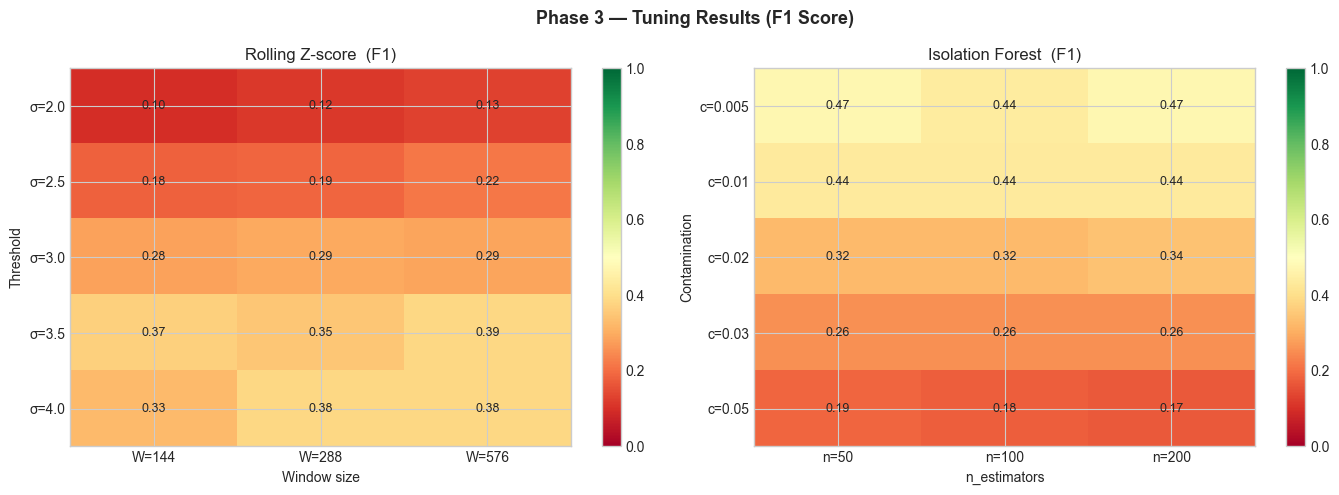

In [24]:
import matplotlib.ticker as ticker
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 3 — Tuning Results (F1 Score)", fontsize=13, fontweight="bold")
# --- Heatmap Z-score ---
pivot_z = df_tune_z.pivot(index="Threshold", columns="Window", values="F1")
im1 = axes[0].imshow(pivot_z.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
axes[0].set_xticks(range(len(pivot_z.columns)))
axes[0].set_yticks(range(len(pivot_z.index)))
axes[0].set_xticklabels([f"W={w}" for w in pivot_z.columns])
axes[0].set_yticklabels([f"σ={t}" for t in pivot_z.index])
axes[0].set_title("Rolling Z-score  (F1)")
axes[0].set_xlabel("Window size")
axes[0].set_ylabel("Threshold")
for i in range(len(pivot_z.index)):
    for j in range(len(pivot_z.columns)):
        axes[0].text(j, i, f"{pivot_z.values[i, j]:.2f}",
                     ha="center", va="center", fontsize=9)
plt.colorbar(im1, ax=axes[0])
# --- Heatmap Isolation Forest (n_estimators=100 slice) ---
pivot_if = (df_tune_if[df_tune_if["n_estimators"] == 100]
            .pivot(index="Contamination", columns="n_estimators", values="F1"))
# Dùng contamination × n_estimators
pivot_if2 = df_tune_if.pivot_table(index="Contamination", columns="n_estimators", values="F1")
im2 = axes[1].imshow(pivot_if2.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
axes[1].set_xticks(range(len(pivot_if2.columns)))
axes[1].set_yticks(range(len(pivot_if2.index)))
axes[1].set_xticklabels([f"n={n}" for n in pivot_if2.columns])
axes[1].set_yticklabels([f"c={c}" for c in pivot_if2.index])
axes[1].set_title("Isolation Forest  (F1)")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("Contamination")
for i in range(len(pivot_if2.index)):
    for j in range(len(pivot_if2.columns)):
        axes[1].text(j, i, f"{pivot_if2.values[i, j]:.2f}",
                     ha="center", va="center", fontsize=9)
plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

### Bảng tổng kết final (best config mỗi detector)

In [25]:
bz = best_z_row
pred_z_best = (
    (df["value"] - df["value"].rolling(int(bz.Window), min_periods=int(bz.Window)//2).mean())
    / df["value"].rolling(int(bz.Window), min_periods=int(bz.Window)//2).std()
).abs() > bz.Threshold
# IF best
bi = best_if_row
clf_best = IsolationForest(
    contamination=bi.Contamination, n_estimators=int(bi.n_estimators), random_state=42
)
clf_best.fit(X)
pred_if_best = (clf_best.predict(X) == -1).astype(int)
final_rows = [
    {
        "Detector": f"Z-score  (W={int(bz.Window)}, σ={bz.Threshold})",
        "Precision": bz.Precision, "Recall": bz.Recall,
        "F1": bz.F1, "False Alarms": int(bz.FalseAlarms)
    },
    {
        "Detector": f"IsoForest (c={bi.Contamination}, n={int(bi.n_estimators)})",
        "Precision": bi.Precision, "Recall": bi.Recall,
        "F1": bi.F1, "False Alarms": int(bi.FalseAlarms)
    },
]
df_final = pd.DataFrame(final_rows).set_index("Detector")
print("=" * 70)
print("   FINAL COMPARISON — Best config sau tuning")
print("=" * 70)
print(df_final.to_string(float_format="{:.4f}".format))
print("=" * 70)
winner = df_final["F1"].idxmax()
print(f"\n🏆 Detector tốt hơn theo F1: {winner}")

   FINAL COMPARISON — Best config sau tuning
                           Precision  Recall     F1  False Alarms
Detector                                                         
Z-score  (W=576, σ=3.5)       0.6111  0.2821 0.3860             7
IsoForest (c=0.005, n=50)     0.7000  0.3590 0.4746             6

🏆 Detector tốt hơn theo F1: IsoForest (c=0.005, n=50)


## Save Model

In [26]:
import joblib
import os
os.makedirs("artifacts", exist_ok=True)
joblib.dump(clf_best, "artifacts/isolation_forest.joblib")
print("Saved: artifacts/isolation_forest.joblib")
print(f"Size: {os.path.getsize('artifacts/isolation_forest.joblib') / 1024:.1f} KB")

Saved: artifacts/isolation_forest.joblib
Size: 566.4 KB
